In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import lineStyles


In [2]:
ucl_df= pd.read_csv("UCI_Credit_Card.csv")
ucl_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          30000 non-null  int64  
 1   LIMIT_BAL                   30000 non-null  float64
 2   SEX                         30000 non-null  int64  
 3   EDUCATION                   30000 non-null  int64  
 4   MARRIAGE                    30000 non-null  int64  
 5   AGE                         30000 non-null  int64  
 6   PAY_0                       30000 non-null  int64  
 7   PAY_2                       30000 non-null  int64  
 8   PAY_3                       30000 non-null  int64  
 9   PAY_4                       30000 non-null  int64  
 10  PAY_5                       30000 non-null  int64  
 11  PAY_6                       30000 non-null  int64  
 12  BILL_AMT1                   30000 non-null  float64
 13  BILL_AMT2                   300

In [4]:
ucl_df.head(10)

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0
5,6,50000.0,1,1,2,37,0,0,0,0,...,19394.0,19619.0,20024.0,2500.0,1815.0,657.0,1000.0,1000.0,800.0,0
6,7,500000.0,1,1,2,29,0,0,0,0,...,542653.0,483003.0,473944.0,55000.0,40000.0,38000.0,20239.0,13750.0,13770.0,0
7,8,100000.0,2,2,2,23,0,-1,-1,0,...,221.0,-159.0,567.0,380.0,601.0,0.0,581.0,1687.0,1542.0,0
8,9,140000.0,2,3,1,28,0,0,2,0,...,12211.0,11793.0,3719.0,3329.0,0.0,432.0,1000.0,1000.0,1000.0,0
9,10,20000.0,1,3,2,35,-2,-2,-2,-2,...,0.0,13007.0,13912.0,0.0,0.0,0.0,13007.0,1122.0,0.0,0


<Axes: >

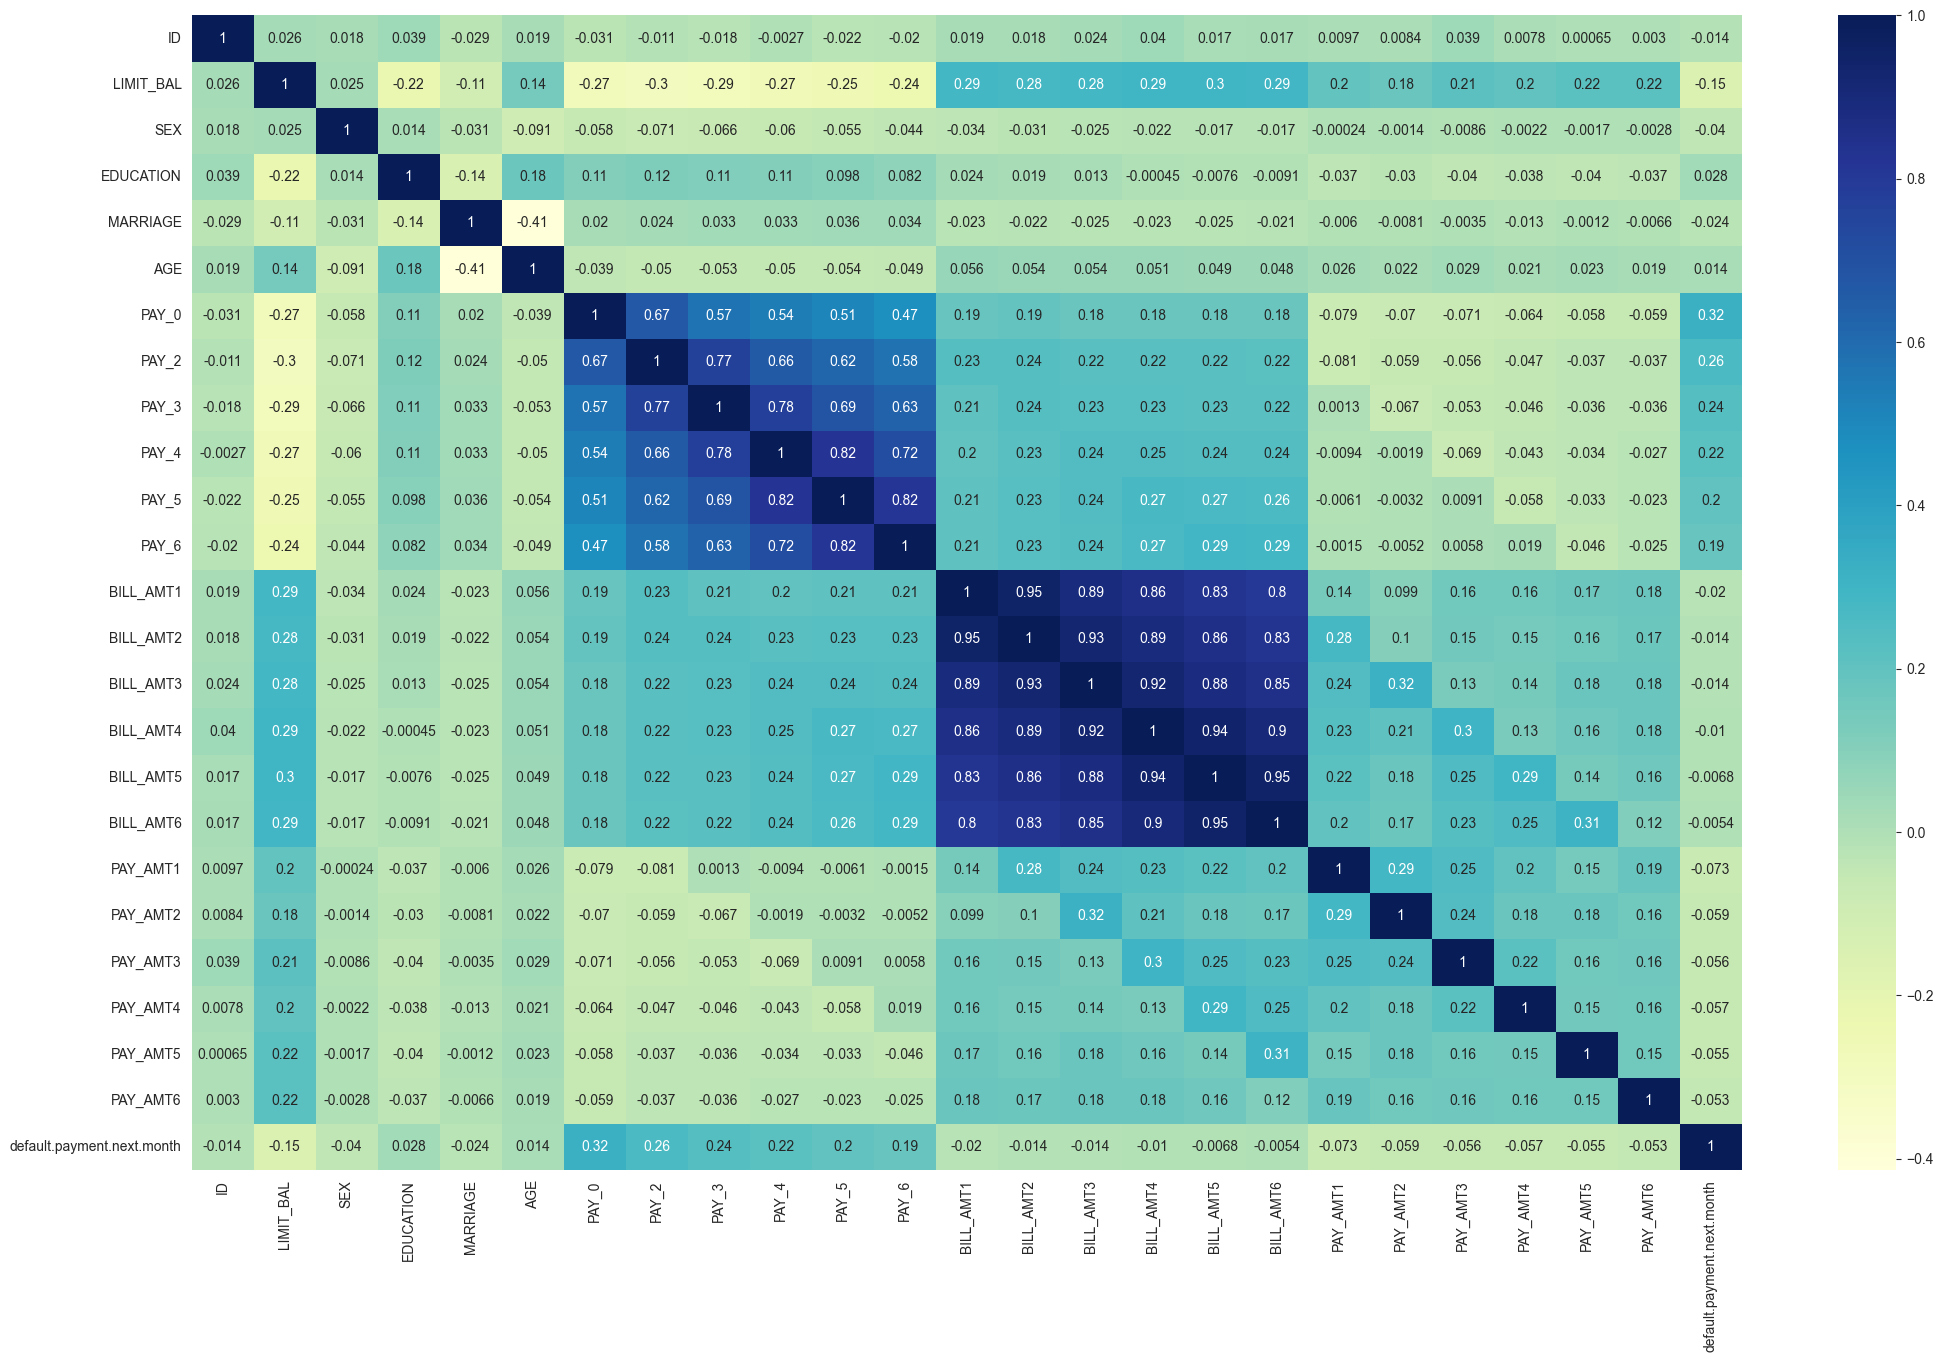

In [12]:
plt.figure(figsize=(25,15))
sns.heatmap(ucl_df.corr(), annot=True, cmap="YlGnBu")

<Axes: xlabel='default.payment.next.month', ylabel='count'>

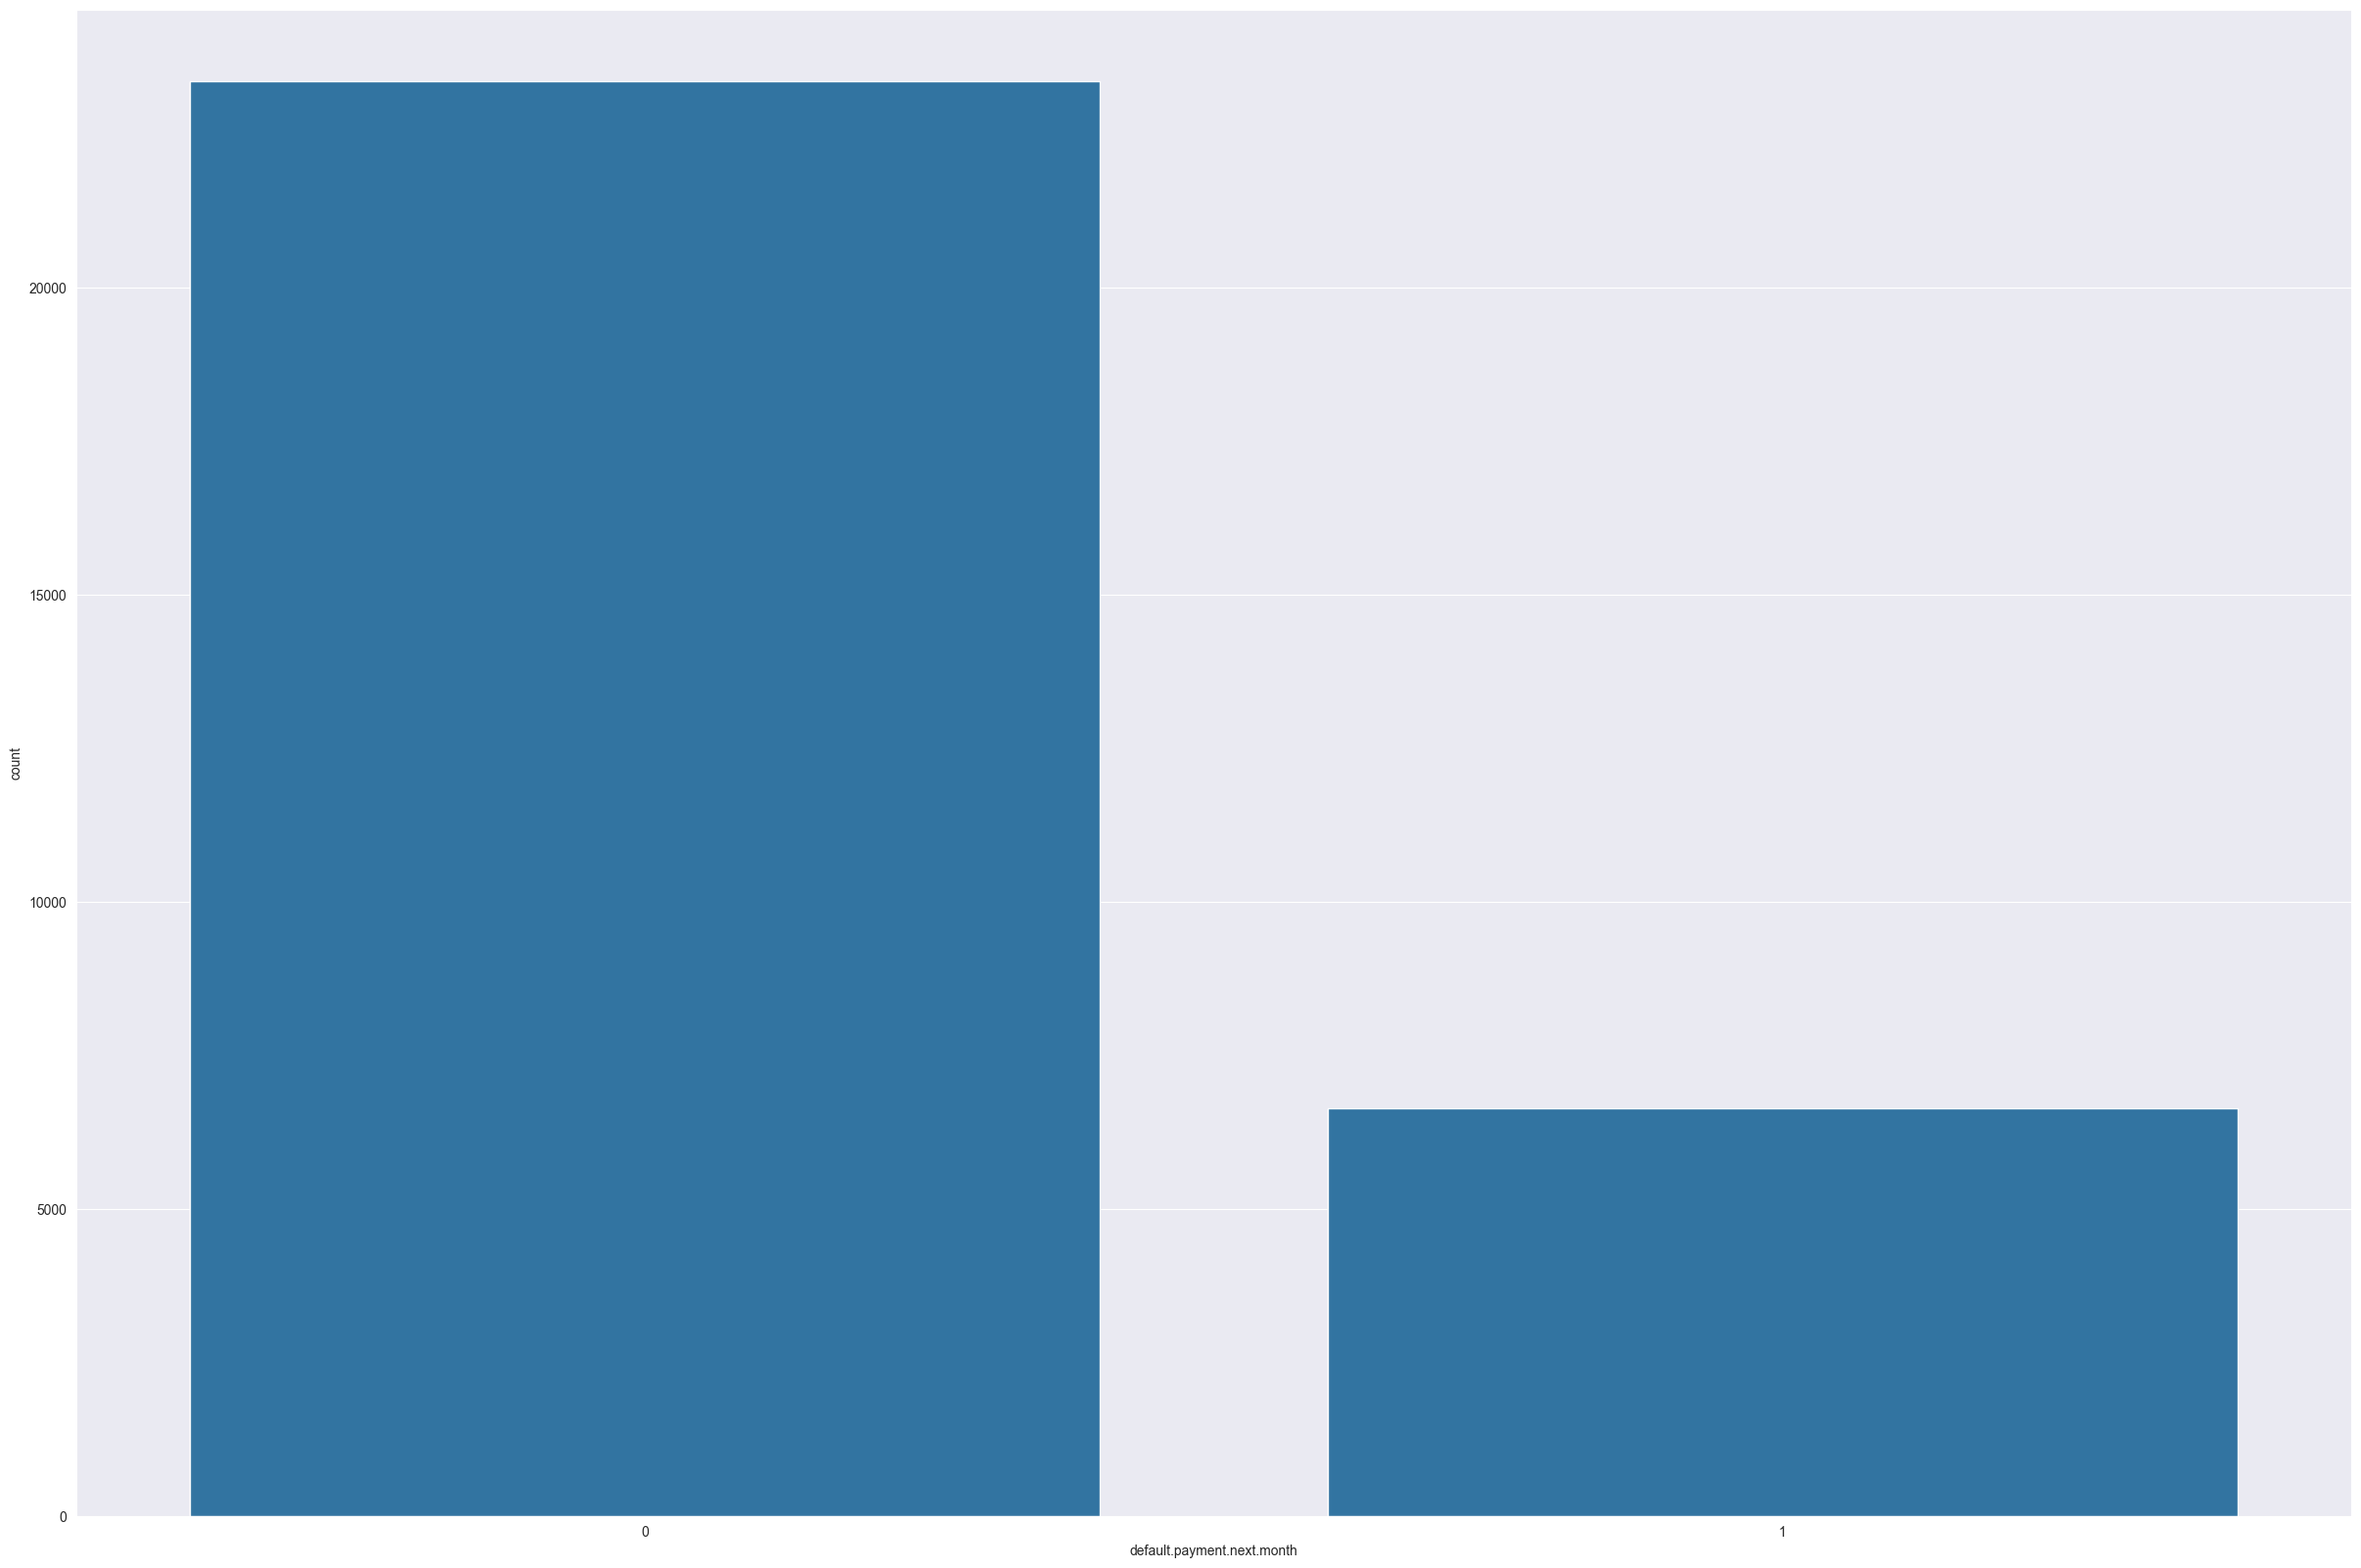

In [4]:
plt.figure(figsize=(30,20))
sns.countplot(x="default.payment.next.month",data=ucl_df)

In [6]:
ucl_df[(ucl_df['default.payment.next.month']==1)].shape

(6636, 25)

In [7]:
ucl_df[(ucl_df['default.payment.next.month']==0)].shape

(23364, 25)

<Axes: xlabel='default.payment.next.month', ylabel='LIMIT_BAL'>

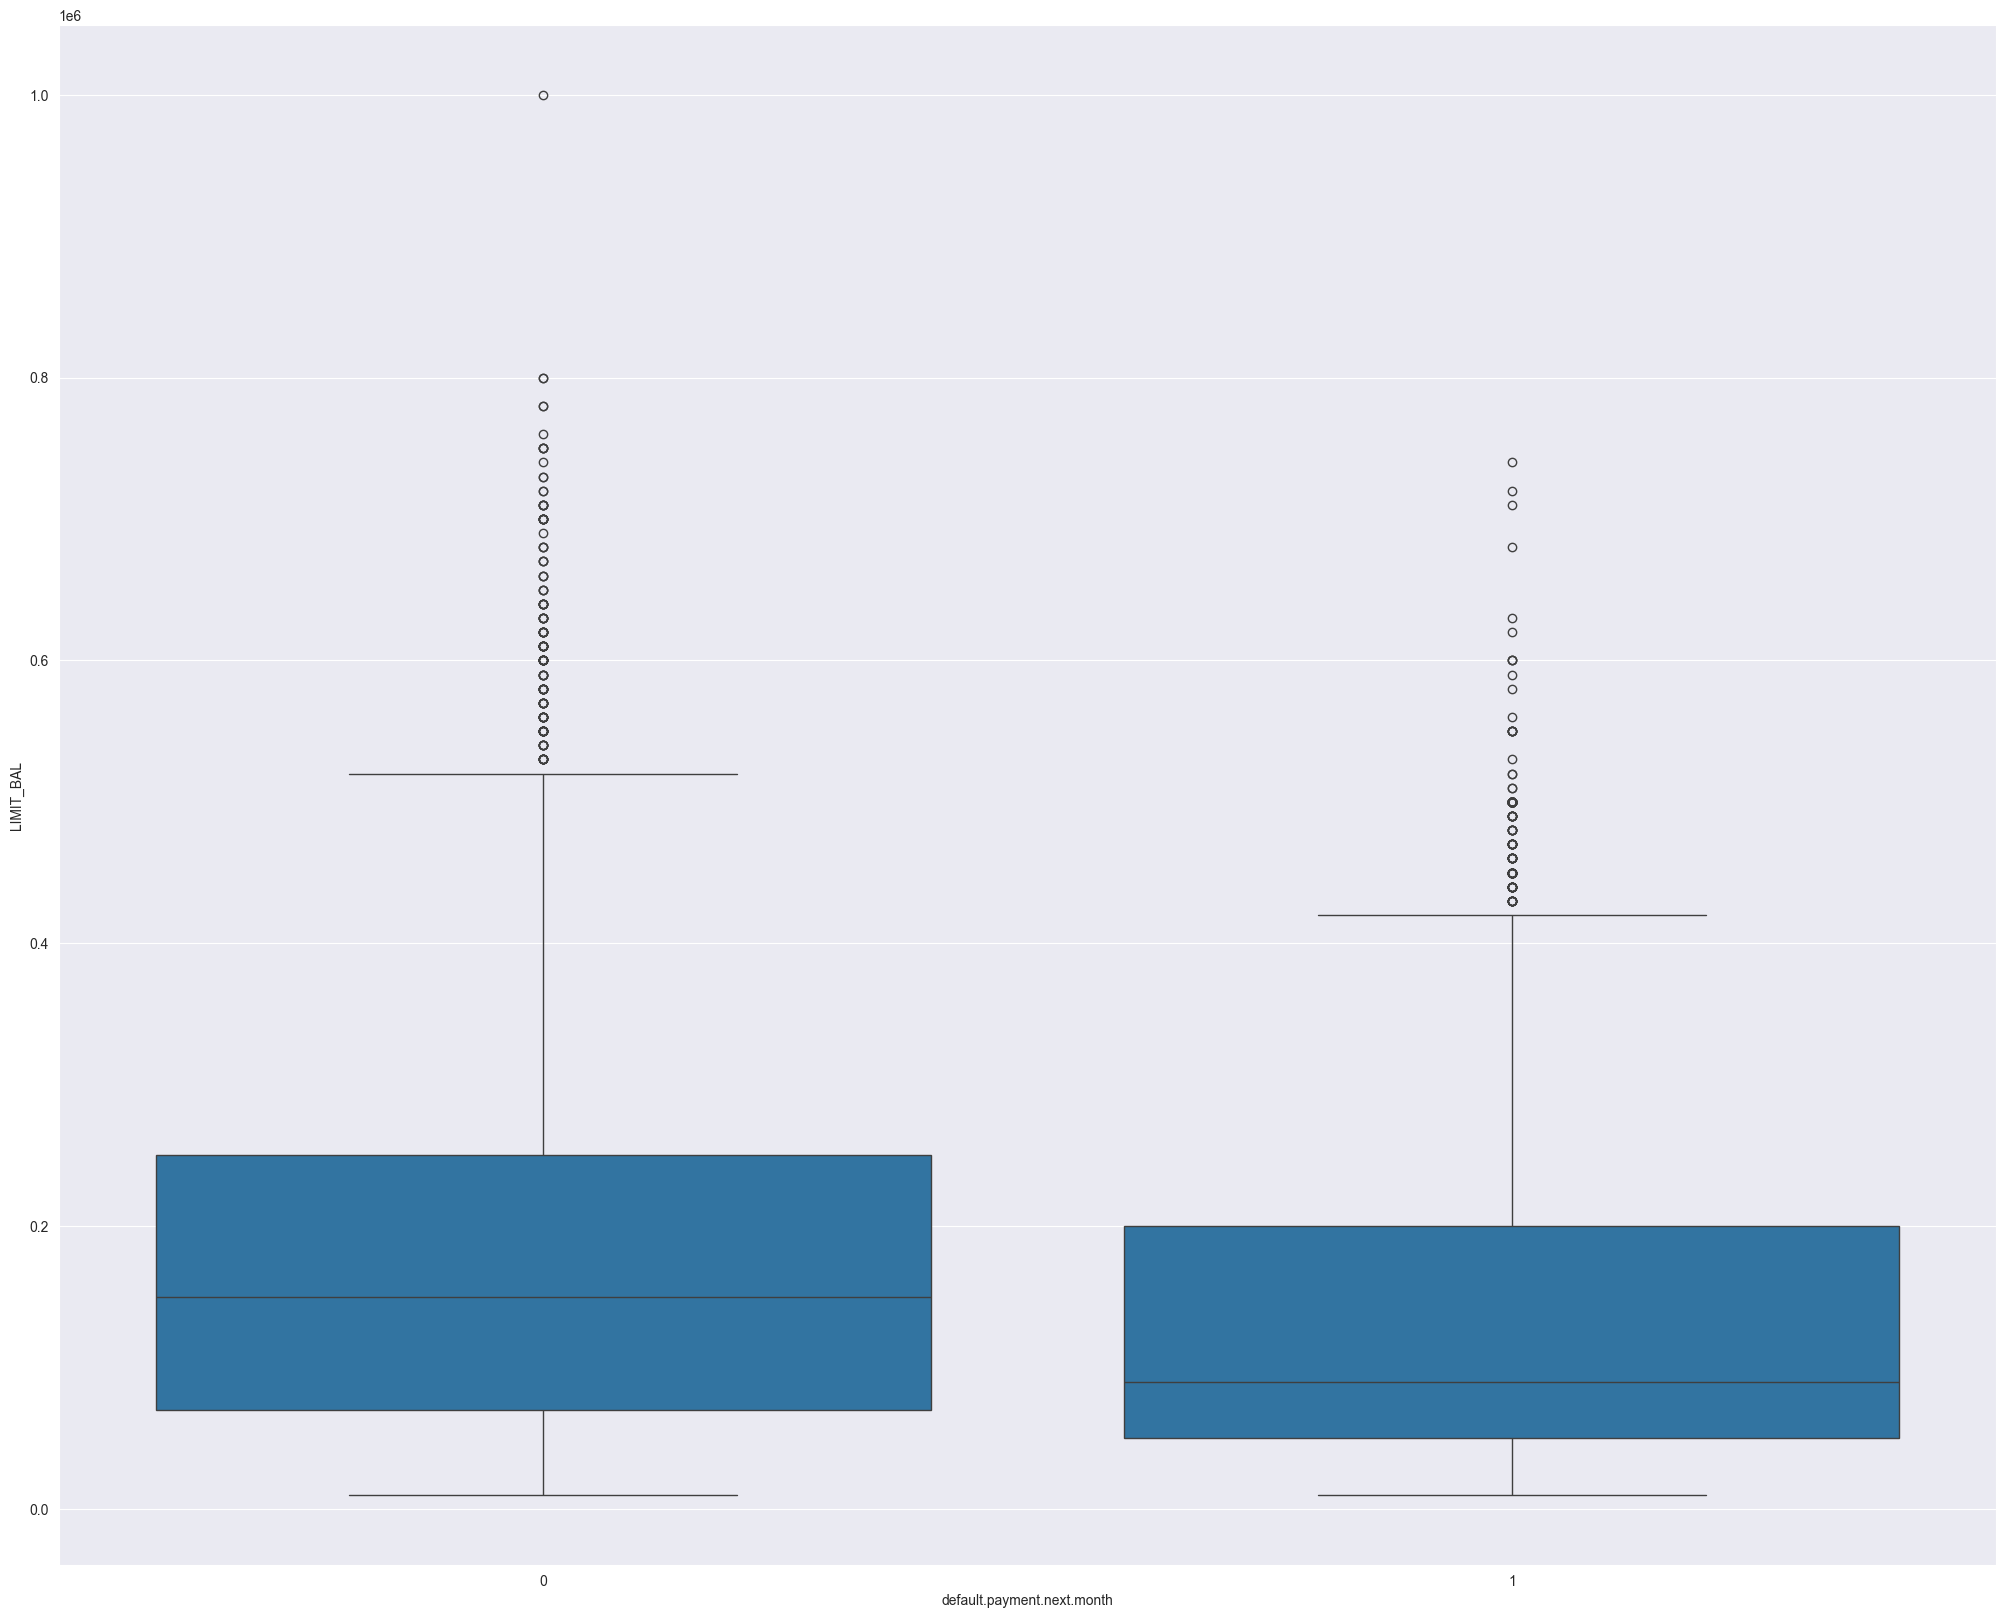

In [13]:
plt.figure(figsize=(25,20))
sns.boxplot(x='default.payment.next.month', y='LIMIT_BAL', data=ucl_df)

**disini kita akan memisahkan data kategorikal nominal/ data kategori yang urutannya tidak berarti tingkatan/ tingkatannya terbalik dengan one hot encode**

In [3]:
from sklearn.preprocessing import OneHotEncoder
x_cat=ucl_df[['SEX','EDUCATION','MARRIAGE']]

In [4]:
encoder=OneHotEncoder()
x_cat=encoder.fit_transform(x_cat).toarray()
x_cat=pd.DataFrame(x_cat)

In [5]:
x_nom=ucl_df.drop(columns=["ID","default.payment.next.month",'SEX','EDUCATION','MARRIAGE'])


disini kita akan menggabungkan x_categoti dengan x_nominal dengan concatenate/concat

In [6]:
x=pd.concat([x_nom,x_cat],axis=1)
y=ucl_df["default.payment.next.month"]

disini kita akan mengubah semua data kolom menjadi string, karena hasil dari one hot encode adalah kolom dengan int 0-12 kalau dari x_cat

In [7]:
x.columns=x.columns.astype(str)

In [8]:
from sklearn.model_selection import train_test_split

**disini stratify berfungsi untuk membagi proporsi dari y agar tetap adil dalam pembagian data, jika proporsi asli adalah data 0 sebanya 78% dan data 1 sebanyak 22%, maka dengan stratify data y_train dan y_test akan tetap dengan proporsi 78 dan 22, caranya adalah mengambil 20% data dari masing2 nilai 0 dan 1 sesuai dengan ketentuan test_size=0.2 dan, lalu menjumlahkannya dan memasukkannya kedalam y_test**

In [11]:
x_train,x_test,y_train,y_test = train_test_split(x,y,stratify=y,test_size=0.2,random_state=42)

In [11]:
y_test.value_counts()

default.payment.next.month
0    4673
1    1327
Name: count, dtype: int64

**sekarang kita mulai akan membuat dan mengevaluasi model ml**

In [14]:
from sklearn.metrics import confusion_matrix,classification_report
from sklearn.preprocessing import StandardScaler,MinMaxScaler

scaler = StandardScaler()
scaler2= MinMaxScaler()
x_trainScaled=scaler.fit_transform(x_train)
x_testScaled=scaler.transform(x_test)
x_trainminmax=scaler2.fit_transform(x_train)
x_testminmax=scaler2.fit_transform(x_test)

**kita akan menggunakan xgboost klasifikasi**

In [15]:
from xgboost import XGBClassifier

count=y_train.value_counts()

disini kita akan menggunakan weight balance khusus untuk xgb,yaitu pos weight yang khusus untuk kelas yes/no atau (1,0) dengan rumus total(0)/total(1)

In [24]:
pos_weight=count[0]/count[1]
model_xgb = XGBClassifier(scale_pos_weight=pos_weight,random_state=42,n_estimators=100,max_depth=4,learning_rate=0.1)
model_xgb.fit(x_train,y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [25]:
y_predict=model_xgb.predict(x_test)
print(classification_report(y_test,y_predict))

              precision    recall  f1-score   support

           0       0.88      0.81      0.84      4673
           1       0.48      0.61      0.54      1327

    accuracy                           0.77      6000
   macro avg       0.68      0.71      0.69      6000
weighted avg       0.79      0.77      0.78      6000



ini adalah mencari max depth dan learning rate terbaik secara manual

In [62]:
best_score=0
best_params=None
for i in range(1,11):
    for a in range(1,11):
        pos_weight=count[0]/count[1]
        model_xgb = XGBClassifier(scale_pos_weight=pos_weight,random_state=42,n_estimators=100,max_depth=i,learning_rate=a/10)
        model_xgb.fit(x_train,y_train)
        y_predict=model_xgb.predict(x_test)
        report=classification_report(y_test,y_predict,output_dict=True)
        current_score=report['1']["f1-score"]
        if current_score > best_score:
            best_score=current_score
            best_params=(i,a/10)

print("best score:",best_score)
print("best param:",best_params)

best score: 0.5384361596832729
best param: (4, 0.1)


**sekarang kita akan mengerjakan svm**

In [27]:
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

In [55]:
model_svc=LinearSVC(class_weight="balanced",max_iter=10000)
model_svm=CalibratedClassifierCV(model_svc)
model_svm.fit(x_trainScaled,y_train)

,estimator,LinearSVC(cla...ax_iter=10000)
,method,'sigmoid'
,cv,None
,n_jobs,None
,ensemble,'auto'
,penalty,'l2'
,loss,'squared_hinge'
,dual,'auto'
,tol,0.0001
,C,1.0
,multi_class,'ovr'


In [56]:
y_predict=model_svm.predict(x_testScaled)
print(classification_report(y_test,y_predict))

              precision    recall  f1-score   support

           0       0.82      0.97      0.89      4673
           1       0.70      0.24      0.36      1327

    accuracy                           0.81      6000
   macro avg       0.76      0.61      0.62      6000
weighted avg       0.79      0.81      0.77      6000



**sekarang kita akan menggunakan naive bayes**

In [36]:
from sklearn.naive_bayes import GaussianNB
model_nb=GaussianNB()
model_nb.fit(x_train,y_train)

,priors,None
,var_smoothing,1e-09


In [37]:
y_predict=model_nb.predict(x_test)
print(classification_report(y_test,y_predict))

              precision    recall  f1-score   support

           0       0.85      0.30      0.45      4673
           1       0.25      0.82      0.38      1327

    accuracy                           0.42      6000
   macro avg       0.55      0.56      0.41      6000
weighted avg       0.72      0.42      0.43      6000



**sekarang kita akan menggunakan logistic regresi**

In [53]:
from sklearn.linear_model import LogisticRegression

model_lr=LogisticRegression(class_weight="balanced")
model_lr.fit(x_trainScaled,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [54]:
y_predict=model_lr.predict(x_testScaled)
print(classification_report(y_test,y_predict))

              precision    recall  f1-score   support

           0       0.87      0.69      0.77      4673
           1       0.37      0.63      0.46      1327

    accuracy                           0.68      6000
   macro avg       0.62      0.66      0.62      6000
weighted avg       0.76      0.68      0.70      6000



**sekarang kita akan menggunakan random forest**

In [70]:
from sklearn.ensemble import RandomForestClassifier

model_rf=RandomForestClassifier(class_weight="balanced",random_state=42,max_depth=6,n_estimators=100)
model_rf.fit(x_train,y_train)


,n_estimators,100
,criterion,'gini'
,max_depth,6
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [71]:
y_predict=model_rf.predict(x_test)
print(classification_report(y_test,y_predict))

              precision    recall  f1-score   support

           0       0.88      0.84      0.86      4673
           1       0.50      0.59      0.54      1327

    accuracy                           0.78      6000
   macro avg       0.69      0.71      0.70      6000
weighted avg       0.79      0.78      0.79      6000



In [69]:
best_score=0
best_params=None

for i in range(1,12):
    model_rf=RandomForestClassifier(class_weight="balanced",random_state=42,max_depth=i,n_estimators=100)
    model_rf.fit(x_train,y_train)
    y_predict=model_rf.predict(x_test)
    report=classification_report(y_test,y_predict,output_dict=True)
    current_score=report['1']["f1-score"]
    if current_score > best_score:
        best_score=current_score
        best_params=i

print("best score:",best_score,"best_params:",best_params)


best score: 0.5408980160111382 best_params: 6


**sekarang kita akan menggunakan k-nearest neighbor**

In [50]:
from sklearn.neighbors import KNeighborsClassifier

model_knn=KNeighborsClassifier()
model_knn.fit(x_trainScaled,y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [51]:
y_predict=model_knn.predict(x_testScaled)
print(classification_report(y_test,y_predict))

              precision    recall  f1-score   support

           0       0.83      0.92      0.87      4673
           1       0.55      0.34      0.42      1327

    accuracy                           0.79      6000
   macro avg       0.69      0.63      0.65      6000
weighted avg       0.77      0.79      0.77      6000



**sekarang kita akan menghitung nilai auc dan roc**

In [34]:
from sklearn import metrics


In [59]:
fpr1,tpr1,thres1=metrics.roc_curve(y_test,model_knn.predict_proba(x_testScaled)[:,1],pos_label=1)
fpr2,tpr2,thres2=metrics.roc_curve(y_test,model_xgb.predict_proba(x_test)[:,1],pos_label=1)
fpr3,tpr3,thres3=metrics.roc_curve(y_test,model_nb.predict_proba(x_test)[:,1],pos_label=1)
fpr4,tpr4,thres4=metrics.roc_curve(y_test,model_rf.predict_proba(x_test)[:,1],pos_label=1)
fpr5,tpr5,thres5=metrics.roc_curve(y_test,model_svm.predict_proba(x_testScaled)[:,1],pos_label=1)
fpr6,tpr6,thres6=metrics.roc_curve(y_test,model_lr.predict_proba(x_testScaled)[:,1],pos_label=1)

hasil score auc

In [72]:
auc_score1=metrics.roc_auc_score(y_test,model_knn.predict_proba(x_testScaled)[:,1])
auc_score2=metrics.roc_auc_score(y_test,model_xgb.predict_proba(x_test)[:,1])
auc_score3=metrics.roc_auc_score(y_test,model_rf.predict_proba(x_test)[:,1])
auc_score4=metrics.roc_auc_score(y_test,model_svm.predict_proba(x_testScaled)[:,1])
auc_score5=metrics.roc_auc_score(y_test,model_nb.predict_proba(x_test)[:,1])
auc_score6=metrics.roc_auc_score(y_test,model_lr.predict_proba(x_testScaled)[:,1])

print("model knn",auc_score1)
print("model xgb",auc_score2)
print("model rf",auc_score3)
print("model svm",auc_score4)
print("model nb",auc_score5)
print("model lr",auc_score6)



model knn 0.6995240822109601
model xgb 0.7159469710957993
model rf 0.7700439972385416
model svm 0.7099991275700601
model nb 0.6516401763501821
model lr 0.7106898147110394


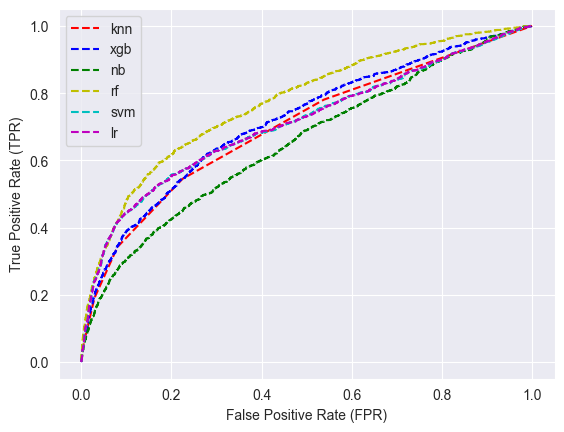

In [73]:
plt.plot(fpr1,tpr1,label='knn',linestyle="--",color='r')
plt.plot(fpr2,tpr2,label='xgb',linestyle="--",color='b')
plt.plot(fpr3,tpr3,label='nb',linestyle="--",color='g')
plt.plot(fpr4,tpr4,label='rf',linestyle="--",color='y')
plt.plot(fpr5,tpr5,label='svm',linestyle="--",color='c')
plt.plot(fpr6,tpr6,label='lr',linestyle="--",color='m')
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.legend()
